In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('/content/Netflix Dataset.csv')
df

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [3]:
df.drop_duplicates(inplace=True)

In [4]:
for col in ['Director', 'Cast', 'Country']:
    df[col].fillna('Unknown', inplace=True)

/tmp/ipython-input-3527994547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [5]:
mode_rating = df['Rating'].mode()[0]
df['Rating'].fillna(mode_rating, inplace=True)
df.dropna(subset=['Release_Date'], inplace=True)

/tmp/ipython-input-3196772915.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(mode_rating, inplace=True)


In [6]:
df

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,Unknown,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [7]:
df['Duration_Value'] = df['Duration'].str.extract(r'(\d+)').astype(int)
df['Duration_Unit'] = df['Duration'].str.extract(r'([A-Za-z\s]+)')
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df.dropna(subset=['Release_Date'], inplace=True) # Drop rows where Release_Date is null after conversion
df['Release_Year'] = df['Release_Date'].dt.year.astype('Int64') # Use nullable integer type

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7689 entries, 0 to 7788
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Show_Id         7689 non-null   object        
 1   Category        7689 non-null   object        
 2   Title           7689 non-null   object        
 3   Director        7689 non-null   object        
 4   Cast            7689 non-null   object        
 5   Country         7689 non-null   object        
 6   Release_Date    7689 non-null   datetime64[ns]
 7   Rating          7689 non-null   object        
 8   Duration        7689 non-null   object        
 9   Type            7689 non-null   object        
 10  Description     7689 non-null   object        
 11  Duration_Value  7689 non-null   int64         
 12  Duration_Unit   7689 non-null   object        
 13  Release_Year    7689 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), int64(1), object(11)
memory u

**Analyze the distribution of Movies vs. TV Shows over the years**

In [9]:
content_by_year_category = df.groupby(['Release_Year', 'Category']).size().reset_index(name='Content_Count')
content_by_year_category = content_by_year_category[content_by_year_category['Release_Year'] >= 2000]

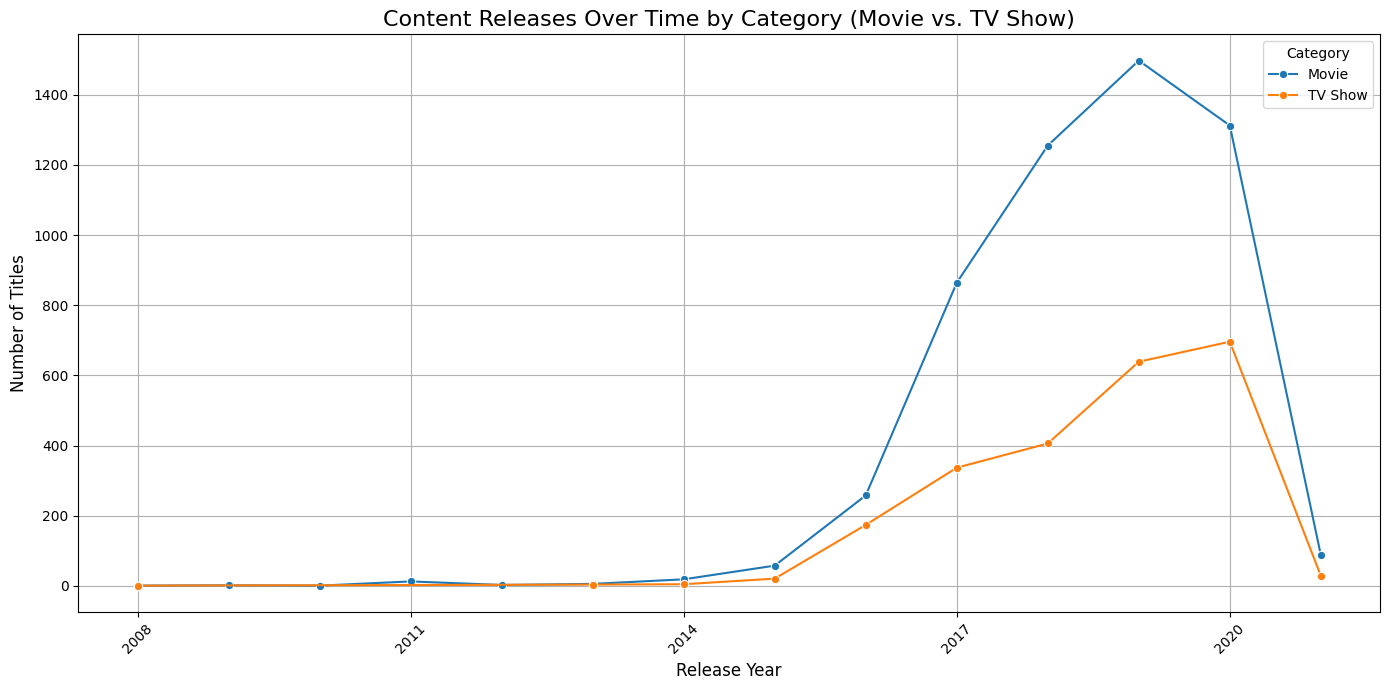

In [10]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=content_by_year_category, x='Release_Year', y='Content_Count', hue='Category', marker='o')
plt.title('Content Releases Over Time by Category (Movie vs. TV Show)', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(title='Category')
plt.xticks(content_by_year_category['Release_Year'].unique()[::3], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Identify the most common genres**

In [11]:
df_genres = df.assign(Genre=df['Type'].str.split(', ')).explode('Genre')
top_genres = df_genres['Genre'].value_counts().nlargest(10)

/tmp/ipython-input-3326031123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='magma')


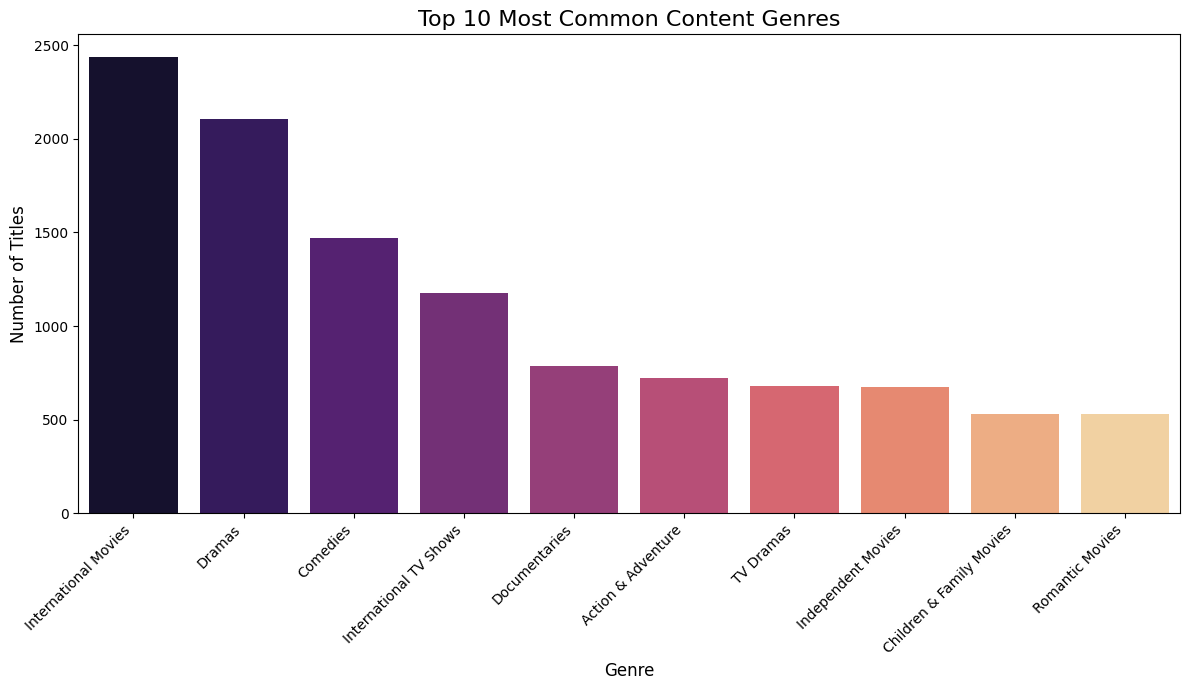

In [12]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='magma')
plt.title('Top 10 Most Common Content Genres', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
print("\nTop 10 Genres:")
print(top_genres)


Top 10 Genres:
Genre
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1176
Documentaries                786
Action & Adventure           721
TV Dramas                    680
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64


**Compare country-wise contributions to Netflix’s catalog**

In [14]:
country_df = df.copy()
country_df['First_Country'] = country_df['Country'].apply(lambda x: x.split(',')[0].strip() if x != 'Unknown' else 'Unknown')
top_countries = country_df[country_df['First_Country'] != 'Unknown']['First_Country'].value_counts().nlargest(10)

/tmp/ipython-input-766139124.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='plasma')


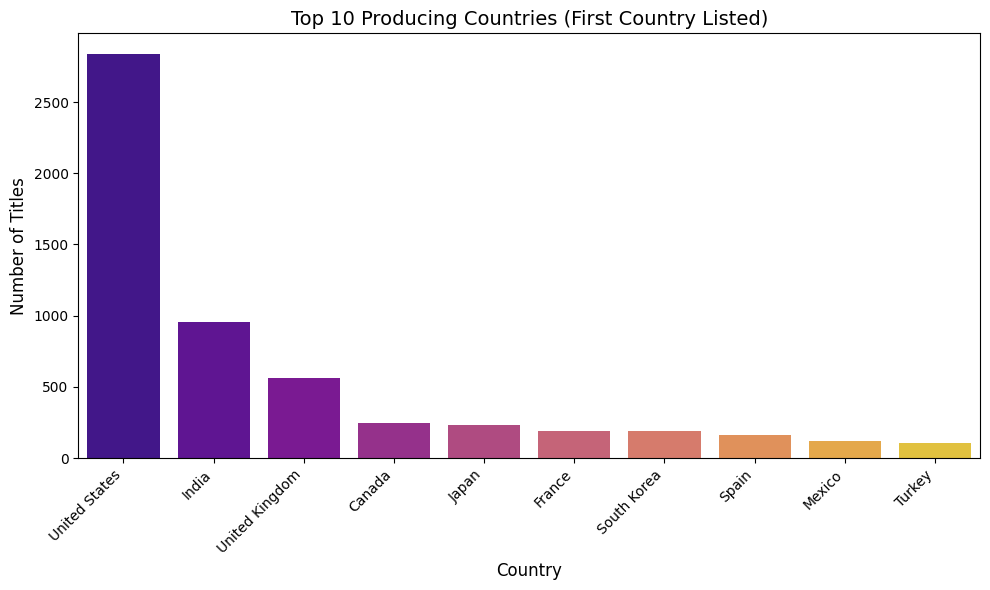

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='plasma')
plt.title('Top 10 Producing Countries (First Country Listed)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

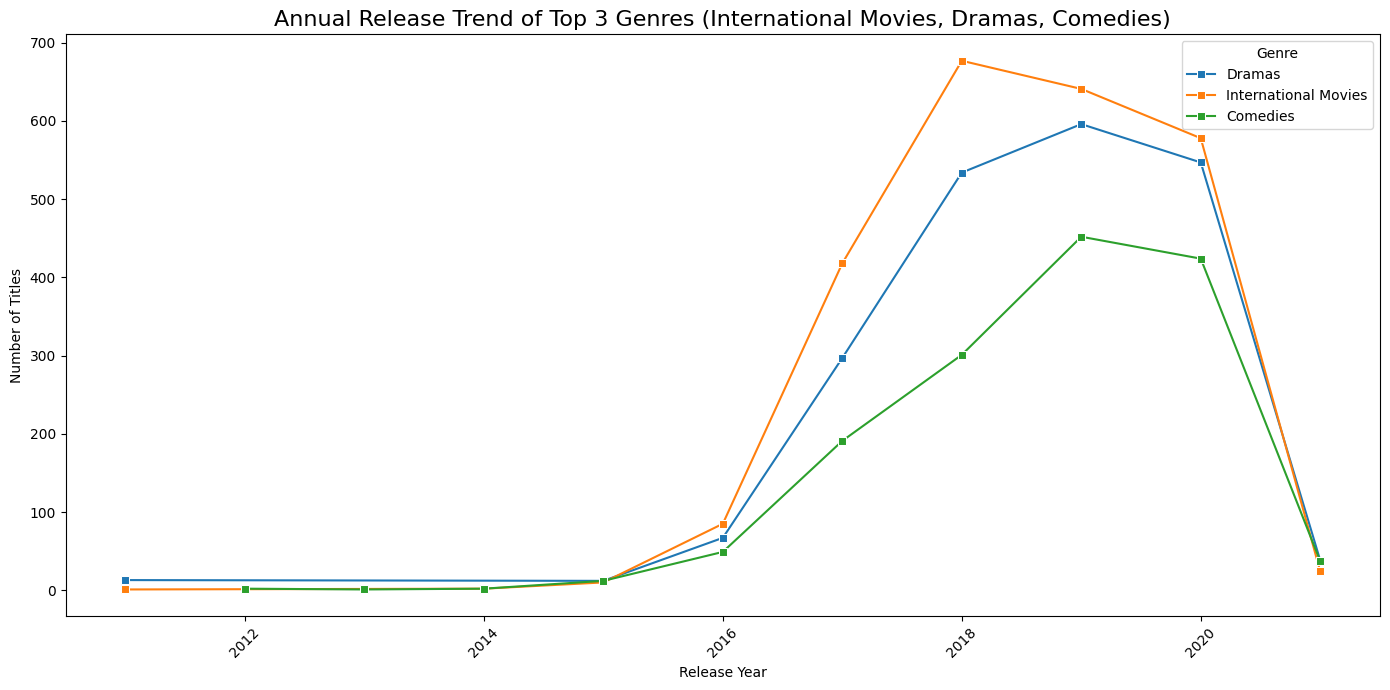

In [16]:
top_3_genres = top_genres.index[:3]
df_genre_trend = df_genres[df_genres['Genre'].isin(top_3_genres)]

genre_yearly_counts = df_genre_trend.groupby(['Release_Year', 'Genre']).size().reset_index(name='Content_Count')
genre_yearly_counts = genre_yearly_counts[genre_yearly_counts['Release_Year'] >= 2010] # Focus on the last decade

plt.figure(figsize=(14, 7))
sns.lineplot(data=genre_yearly_counts, x='Release_Year', y='Content_Count', hue='Genre', marker='s')
plt.title(f'Annual Release Trend of Top 3 Genres ({", ".join(top_3_genres)})', fontsize=16)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('3_1_Top_Genre_Trend_Over_Time.png')
plt.show()

In [17]:
print("\nTop 10 Producing Countries:")
print(top_countries)


Top 10 Producing Countries:
First_Country
United States     2841
India              955
United Kingdom     560
Canada             247
Japan              233
France             193
South Korea        189
Spain              164
Mexico             123
Turkey             106
Name: count, dtype: int64


In [18]:
rating_counts = df['Rating'].value_counts()
print("\nContent Rating Distribution:")
print(rating_counts)


Content Rating Distribution:
Rating
TV-MA       2846
TV-14       1904
TV-PG        781
R            665
PG-13        386
TV-Y         273
TV-Y7        267
PG           247
TV-G         186
NR            82
G             39
TV-Y7-FV       5
UR             5
NC-17          3
Name: count, dtype: int64


In [19]:
movie_avg_duration = df[df['Duration_Unit'] == ' min']['Duration_Value'].mean()
tv_show_avg_seasons = df[df['Duration_Unit'] == ' Seasons']['Duration_Value'].mean()
print(f"\nAverage Movie Duration: {movie_avg_duration:.2f} minutes")
print(f"Average TV Show Seasons: {tv_show_avg_seasons:.2f} seasons")


Average Movie Duration: 99.31 minutes
Average TV Show Seasons: 3.26 seasons
